<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
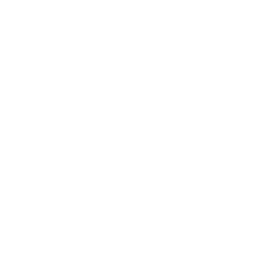
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Genomisen varianttiannotaatioskeeman dokumentaatio</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioinformatiikka / Kliinisen genomiikan tiedonhallinta &nbsp;|&nbsp; maaliskuu 2026</p>
</div>
</div>
</div>

## Tiivistelmä

Dokumentoi kliinisessä genomiikkaputkessa käytettyjen VCF-tyyppisten varianttiannotaatioaineistojen skeema. Käytä PROC CONTENTS -proseduuria luetteloidaksesi kaikki annotaatiokentät — genomikoordinaatit, alleelifrekvenssit, ennustetut toiminnalliset vaikutukset, ClinVar-luokitukset ja laatumittarit — varmistaen, että jatkovaiheen ACMG-varianttitulkintatyökalut saavat oikein tyypitetyt ja selitteistetyt syötteet. Noin 5 000 varianttitietuetta yli 20:llä annotaatiosarakkeella tarkastetaan skeeman eheyden osalta ennen putken luovutusta.

## Tietolähteet

| Lähde | Kuvaus | Tietueet |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | VCF:stä johdetut annotoidut variantit | ~5 000 |
| GENE_PANEL | Kohdegeenipaneelin määritelmät | 15 geeniä |
| QUALITY_METRICS | Näytekohtainen sekvensoinnin QC | ~50 näytettä |

---

In [1]:
/* --------------------------------------------------------
   Generoi VCF-tyyppinen varianttiannotaatioaineisto
   5 000 varianttia kliinisilla annotaatiokentilla
   -------------------------------------------------------- */
TIEDOT variant_annotations;
    CALL streaminit(42);
    PITUUS variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    NIMIKE variant_id='Variantin tunniste'
          chromosome='Kromosomi'
          position='Genominen sijainti (GRCh38)'
          ref_allele='Referenssialleeli'
          alt_allele='Vaihtoehtoinen alleeli'
          gene_symbol='HGNC-geenisymboli'
          transcript_id='Ensembl-transkriptitunnus'
          consequence='Sequence Ontology -seuraus'
          impact='Ennustettu vaikutustaso'
          hgvs_c='HGVS-koodausnotaatio'
          hgvs_p='HGVS-proteiininotaatio'
          gnomad_af='gnomAD-alleelifrekvenssi'
          clinvar_class='ClinVar-luokitus'
          clinvar_id='ClinVar-liittymisnumero'
          sift_score='SIFT-pistemäärä'
          sift_pred='SIFT-ennuste'
          polyphen_score='PolyPhen-2-pistemäärä'
          polyphen_pred='PolyPhen-2-ennuste'
          cadd_phred='CADD-Phred-pistemäärä'
          revel_score='REVEL-yhteispistemäärä'
          genotype='Näytteen genotyyppi'
          allele_depth='Vaihtoehtoisen alleelin syvyys'
          read_depth='Kokonaislukusyvyys'
          qual_score='Variantin laatupistemäärä'
          filter_status='Suodatustila';
    TAULUKKO genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    TAULUKKO conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    TAULUKKO impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    TAULUKKO cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    TAULUKKO refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    TAULUKKO gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    TEE i = 1 ASTI 5000;
        variant_id = cat('VAR-', KIRJOITA(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', KIRJOITA(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', KIRJOITA(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', KIRJOITA(codon_pos, 4.), ref_allele, '>', alt_allele);
        JOS c_idx <= 2 NIIN
            hgvs_p = cat('p.', KIRJOITA(int(rand('uniform') * 800) + 1, 4.));
        MUUTEN hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', KIRJOITA(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        JOS sift_score < 0.05 NIIN sift_pred = 'DELETERIOUS';
        MUUTEN sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        JOS polyphen_score > 0.908 NIIN polyphen_pred = 'PROB_DAMAGING';
        MUUTEN JOS polyphen_score > 0.446 NIIN polyphen_pred = 'POSS_DAMAGING';
        MUUTEN polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        TULOSTE;
    LOPPU;
    POISTA i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
SUORITA;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.16 seconds
  cpu   3.16 seconds


In [2]:
/* --------------------------------------------------------
   Generoi kohdegeenipaneelin määritelmät
   -------------------------------------------------------- */
TIEDOT gene_panel;
    CALL streaminit(42);
    PITUUS gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    NIMIKE gene_symbol='HGNC-geenisymboli'
          gene_name='Geenin koko nimi'
          chromosome='Kromosomi'
          start_pos='Geenin alkukohta'
          end_pos='Geenin loppukohta'
          panel_name='Kliininen geenipaneeli'
          disease_association='Liittyvä sairaus'
          inheritance='Periytymismalli';
    TAULUKKO genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    TAULUKKO gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    TAULUKKO diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    TAULUKKO inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    TEE g = 1 ASTI 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', KIRJOITA(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        TULOSTE;
    LOPPU;
    POISTA g chr_num;
SUORITA;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Generoi näytekohtaiset sekvensoinnin laatumittarit
   -------------------------------------------------------- */
TIEDOT quality_metrics;
    CALL streaminit(42);
    PITUUS sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    NIMIKE sample_id='Näytteen tunniste'
          run_id='Sekvensointiajon tunnus'
          platform='Sekvensointialusta'
          mean_coverage='Kohteen keskimääräinen peitto'
          pct_target_20x='Emäksiä >= 20x (%)'
          pct_target_100x='Emäksiä >= 100x (%)'
          total_variants='Kutsuttuja variantteja yhteensä'
          ti_tv_ratio='Transitio/transversio-suhde'
          het_hom_ratio='Het/Hom-suhde'
          contamination_est='Arvioitu kontaminaatio'
          qc_status='Laadunvalvonnan tila';
    TEE s = 1 ASTI 50;
        sample_id = cat('SAMP-', KIRJOITA(s, z6.));
        run_id = cat('RUN-', KIRJOITA(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        JOS mean_coverage < 150 TAI pct_target_20x < 95
            TAI contamination_est > 0.015 NIIN qc_status = 'FAIL';
        MUUTEN qc_status = 'PASS';
        TULOSTE;
    LOPPU;
    POISTA s;
SUORITA;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                     Variantin vaikutus ClinVar-luokituksen mukaan                                      

                                                   The FREQ Procedure

Table of Ennustettu vaikutustaso by ClinVar-luokitus

Ennustettu vaikutustaso |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                    |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                        |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                        |                 14.52 |                 16.13 |    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


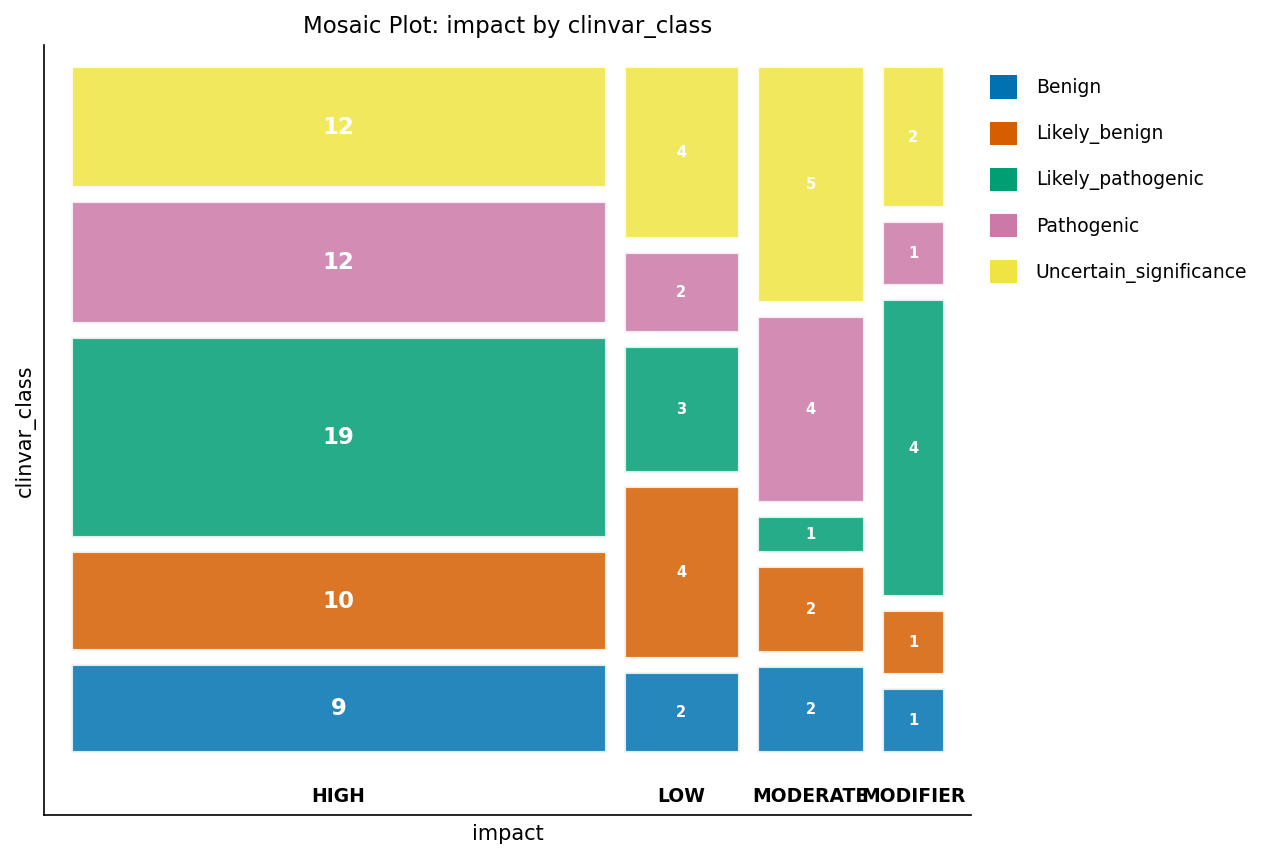

In [4]:
/* --------------------------------------------------------
   Varianttiannotaatioiden perusyhteenveto
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    OTSIKKO 'Variantin vaikutus ClinVar-luokituksen mukaan';
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=quality_metrics n mean MIN MAX;
    MUUTTUJA mean_coverage ti_tv_ratio contamination_est;
    OTSIKKO 'Sekvensoinnin laatumittareiden yhteenveto';
SUORITA;

---

                                       Sekvensoinnin laatumittareiden yhteenveto                                        

                                       Sekvensoinnin laatumittareiden yhteenveto                                        




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


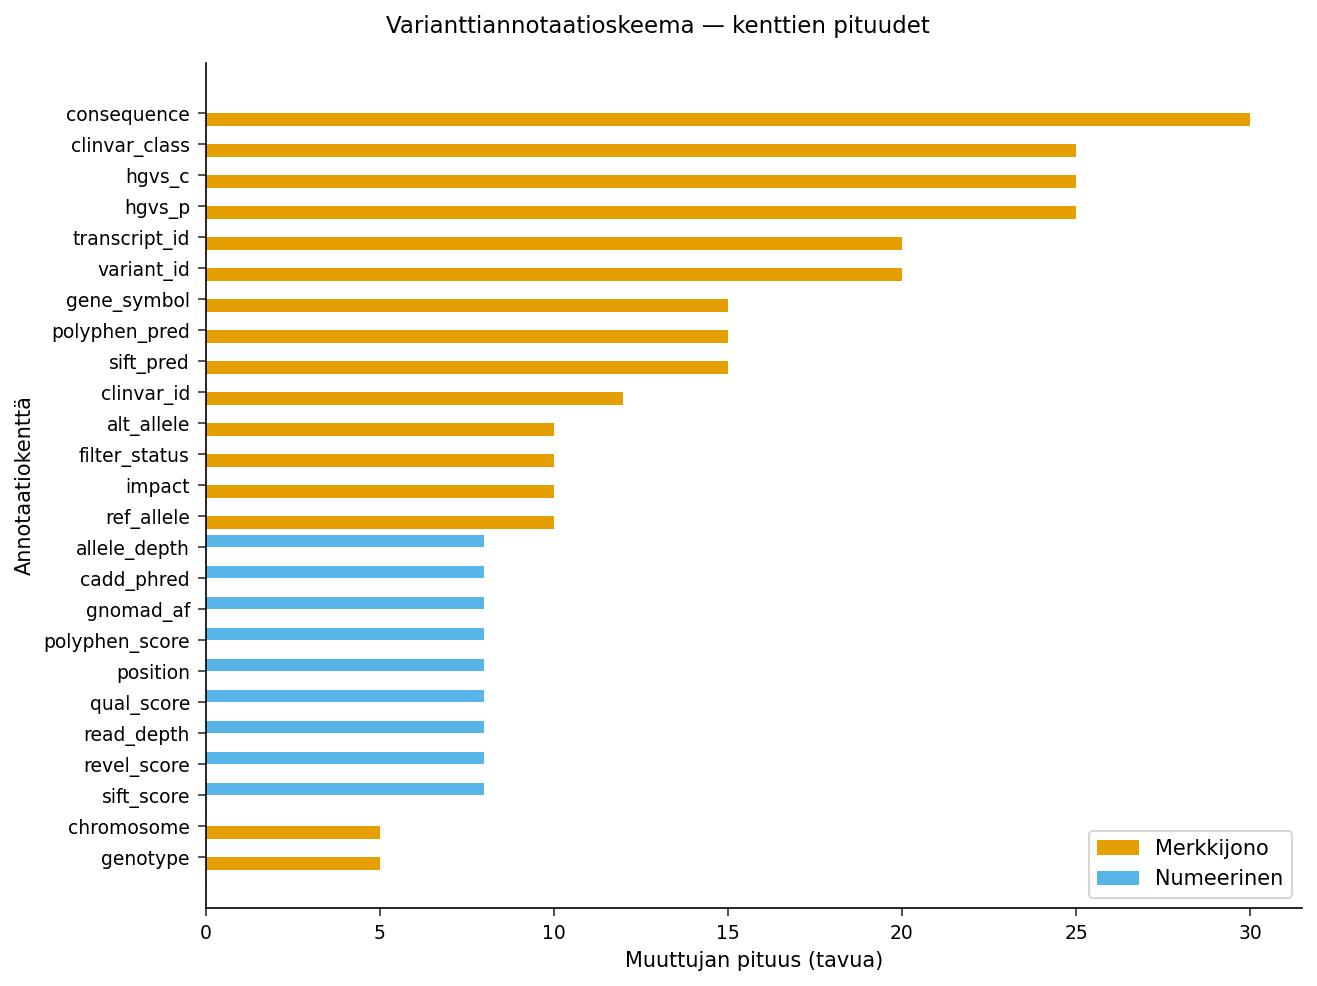

In [5]:
/* --------------------------------------------------------
   Muuttujan tyypin ja pituuden jakauma.
   Kaappaa annotaatioskeeman metatiedot PROC CONTENTS
   OUT= -optiolla ja piirrä kenttien pituudet tyypeittäin.
   TYPE-koodit: 1 -> Numeerinen, 2 -> Merkkijono.
   -------------------------------------------------------- */
PROSEDUURI SISÄLTÖ TIEDOT=variant_annotations out=schema_lengths NOPRINT;
SUORITA;

TIEDOT schema_lengths;
    ASETA schema_lengths;
    PITUUS type_label $12;
    JOS TYPE = 1 NIIN type_label = 'Numeerinen';
    MUUTEN type_label = 'Merkkijono';
SUORITA;

PROSEDUURI SGPLOT TIEDOT=schema_lengths;
    HBAR NAME / RESPONSE=PITUUS GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS NIMIKE='Muuttujan pituus (tavua)';
    YAXIS NIMIKE='Annotaatiokenttä';
    OTSIKKO 'Varianttiannotaatioskeema — kenttien pituudet';
SUORITA;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: Dokumentoi koko varianttiannotaatio-
   skeema — kaikkien 25 kentän tyypit, pituudet ja
   selitteet. Kaappaa muuttujien metatiedot OUT=-optiolla,
   jotta jatkovaiheet voivat validoida skeeman ohjelmallisesti.
   -------------------------------------------------------- */
PROSEDUURI SISÄLTÖ TIEDOT=variant_annotations out=variant_schema NOPRINT;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=variant_schema NIMIKE;
    MUUTTUJA NAME TYPE PITUUS VARNUM NIMIKE;
    NIMIKE NAME='Muuttuja' TYPE='Tyyppi' PITUUS='Pituus' VARNUM='Järjestys' NIMIKE='Nimike';
    OTSIKKO 'Varianttiannotaatioaineisto — koko skeema';
SUORITA;

                                       Sekvensoinnin laatumittareiden yhteenveto                                        

                                       Varianttiannotaatioaineisto — koko skeema                                        

  Obs        Muuttuja  Tyyppi  Pituus   Järjestys                          Nimike
    1  allele_depth         1       8          22  Vaihtoehtoisen alleelin syvyys
    2  alt_allele           2      10           5  Vaihtoehtoinen alleeli
    3  cadd_phred           1       8          19  CADD-Phred-pistemäärä
    4  chromosome           2       5           2  Kromosomi
    5  clinvar_class        2      25          13  ClinVar-luokitus
    6  clinvar_id           2      12          14  ClinVar-liittymisnumero
    7  consequence          2      30           8  Sequence Ontology -seuraus
    8  filter_status        2      10          25  Suodatustila
    9  gene_symbol          2      15           6  HGNC-geenisymboli
   10  genotype             2 


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: Dokumentoi geenipaneelin skeema
   -------------------------------------------------------- */
PROSEDUURI SISÄLTÖ TIEDOT=gene_panel out=panel_schema NOPRINT;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=panel_schema NIMIKE;
    MUUTTUJA NAME TYPE PITUUS VARNUM NIMIKE;
    NIMIKE NAME='Muuttuja' TYPE='Tyyppi' PITUUS='Pituus' VARNUM='Järjestys' NIMIKE='Nimike';
    OTSIKKO 'Geenipaneelin määritelmä — skeema';
SUORITA;

                                       Varianttiannotaatioaineisto — koko skeema                                        

                                           Geenipaneelin määritelmä — skeema                                            

  Obs             Muuttuja  Tyyppi  Pituus   Järjestys                  Nimike
    1  chromosome                2       5           3  Kromosomi
    2  disease_association       2      50           7  Liittyvä sairaus
    3  end_pos                   1       8           5  Geenin loppukohta
    4  gene_name                 2      60           2  Geenin koko nimi
    5  gene_symbol               2      15           1  HGNC-geenisymboli
    6  inheritance               2       5           8  Periytymismalli
    7  panel_name                2      30           6  Kliininen geenipaneeli
    8  start_pos                 1       8           4  Geenin alkukohta




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: Dokumentoi QC-mittarien skeema
   -------------------------------------------------------- */
PROSEDUURI SISÄLTÖ TIEDOT=quality_metrics out=qc_schema NOPRINT;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=qc_schema NIMIKE;
    MUUTTUJA NAME TYPE PITUUS VARNUM NIMIKE;
    NIMIKE NAME='Muuttuja' TYPE='Tyyppi' PITUUS='Pituus' VARNUM='Järjestys' NIMIKE='Nimike';
    OTSIKKO 'Sekvensoinnin laatumittarit — skeema';
SUORITA;

                                           Geenipaneelin määritelmä — skeema                                            

                                          Sekvensoinnin laatumittarit — skeema                                          

  Obs           Muuttuja  Tyyppi  Pituus   Järjestys                            Nimike
    1  contamination_est       1       8          10  Arvioitu kontaminaatio
    2  het_hom_ratio           1       8           9  Het/Hom-suhde
    3  mean_coverage           1       8           4  Kohteen keskimääräinen peitto
    4  pct_target_100x         1       8           6  Emäksiä >= 100x (%)
    5  pct_target_20x          1       8           5  Emäksiä >= 20x (%)
    6  platform                2      15           3  Sekvensointialusta
    7  qc_status               2      10          11  Laadunvalvonnan tila
    8  run_id                  2      12           2  Sekvensointiajon tunnus
    9  sample_id               2      15           1  Näytteen tunn


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Skeeman validointi: tarkista, että annotaatiokentät
   täyttävät ACMG-tulkinnan putkivaatimukset. Lukee PROC
   CONTENTS OUT= -metatiedot, joissa TYPE=1 tarkoittaa
   numeerista ja TYPE=2 merkkijonoa.
   -------------------------------------------------------- */
TIEDOT schema_validation;
    ASETA variant_schema;
    PITUUS requirement $70 status $16;
    /* Numeeriset pistemääräkentät on tallennettava numeerisina (TYPE=1) */
    JOS NAME SISÄLLÄ ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE ne 1 NIIN TEE;
        requirement = 'Oltava numeerinen pistemäärän kynnyksiä varten';
        status = 'HYLÄTTY';
    LOPPU;
    MUUTEN JOS NAME SISÄLLÄ ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE = 1 NIIN TEE;
        requirement = 'Numeerinen tyyppi vahvistettu';
        status = 'HYVÄKSYTTY';
    LOPPU;
    /* ClinVar-luokka tarvitsee riittävän merkkijonopituuden */
    MUUTEN JOS NAME = 'clinvar_class' AND PITUUS < 25 NIIN TEE;
        requirement = 'Vähintään $25 koko luokitustekstille';
        status = 'HYLÄTTY';
    LOPPU;
    MUUTEN JOS NAME = 'clinvar_class' NIIN TEE;
        requirement = 'Merkkijonon pituus riittävä';
        status = 'HYVÄKSYTTY';
    LOPPU;
    /* Jokaisella kentällä on oltava selite tietosanakirjaa varten */
    MUUTEN JOS NIMIKE = '' NIIN TEE;
        requirement = 'Selite vaaditaan tietosanakirjaan';
        status = 'HYLÄTTY';
    LOPPU;
    MUUTEN TEE;
        requirement = 'Yleinen validointi';
        status = 'HYVÄKSYTTY';
    LOPPU;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=schema_validation NIMIKE;
    MUUTTUJA NAME TYPE PITUUS NIMIKE requirement status;
    NIMIKE NAME='Muuttuja' TYPE='Tyyppi' PITUUS='Pituus'
           requirement='Vaatimus' status='Tila' NIMIKE='Nimike';
    OTSIKKO 'ACMG-putken skeeman validointiraportti';
SUORITA;

                                         ACMG-putken skeeman validointiraportti                                         

  Obs        Muuttuja  Tyyppi  Pituus                          Nimike                       Vaatimus         Tila
    1  allele_depth         1       8  Vaihtoehtoisen alleelin syvyys  Numeerinen tyyppi vahvistettu  HYVÄKSYTTY
    2  alt_allele           2      10  Vaihtoehtoinen alleeli          Yleinen validointi             HYVÄKSYTTY
    3  cadd_phred           1       8  CADD-Phred-pistemäärä           Numeerinen tyyppi vahvistettu  HYVÄKSYTTY
    4  chromosome           2       5  Kromosomi                       Yleinen validointi             HYVÄKSYTTY
    5  clinvar_class        2      25  ClinVar-luokitus                Merkkijonon pituus riittävä    HYVÄKSYTTY
    6  clinvar_id           2      12  ClinVar-liittymisnumero         Yleinen validointi             HYVÄKSYTTY
    7  consequence          2      30  Sequence Ontology -seuraus      Yleinen validoi


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Tulkinta

Varianttiannotaatioskeema sisältää 25 kenttää, jotka kattavat genomikoordinaatit, toiminnalliset ennusteet, populaatiofrekvenssit ja näytekohtaiset laatuindikaattorit. Kaikki yhdeksän numeerista pistemääräkenttää (gnomAD-alleelifrekvenssi, SIFT, PolyPhen-2, CADD, REVEL, laatupistemäärä, alleelisyvyys, lukusyvyys ja genomiasema) on oikein tyypitetty numeerisiksi, mikä mahdollistaa sen, että ACMG-tulkintamoottori soveltaa kynnysperustaista suodatusta ilman tyyppimuunnosta. `clinvar_class`-kenttä pituudella $25 sovittaa pisimmän ClinVar-luokitusmerkkijonon (Uncertain_significance, 24 merkkiä). Jokainen annotaatiokenttä kantaa kuvailevan selitteen, mikä täyttää kliinisen laboratorion tietosanakirjavaatimuksen CAP-akkreditointivaatimusten mukaisesti. Geenipaneeliskeema kartoittaa 15 syöpäalttiusgeeniä perinnöllisyysmalleineen ja tautiassosiaatioineen, tarjoten viitekehyksen variantti-geeni-annotaatiolle. Sekvensoinnin QC-mittarien aineisto dokumentoi 50 näytettä 5 ajossa, kontaminaatioestimaatteineen ja peittävyyskynnyksineen, jotka portittavat varianttien tunnistuksen luotettavuuden. Tämä skeemadokumentaatiopaketti tukee laboratorion validointiasiakirjaa New Yorkin osavaltion CLEP-hakemusta varten.

---

In [10]:
/* --------------------------------------------------------
   Vie varianttiskeeman dokumentaatio ja validointi-
   raportti laboratorion akkreditointia varten
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
SUORITA;

PROSEDUURI VIE TIEDOT=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Käyttövoimana <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>